#### Environment & Engine Loading

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Link to our core engine
sys.path.append(os.path.abspath('..'))
from model import LivelihoodModel

# Professional plotting setup
plt.style.use('ggplot')
%matplotlib inline

print("Logic loaded. Ready to run the 5-year 'No-Action' baseline.")

Logic loaded. Ready to run the 5-year 'No-Action' baseline.


#### Executing the 60-Month Stress Test

In [2]:
# Initialize the 'Control' Model
model = LivelihoodModel(N=1000, intervention="Control")

# Run for 60 steps (each step = 1 month)
for month in range(60):
    model.step()

# Extract the time-series data
baseline_results = model.datacollector.get_model_vars_dataframe()

print("Simulation complete: 60 months of baseline data generated.")
baseline_results.tail(5)

Simulation complete: 60 months of baseline data generated.


,Poverty_Rate,Avg_Savings
55,0.662,331.584267
56,0.727,270.738579
57,0.758,218.674115
58,0.806,175.241937
59,0.150,1335.787649


#### Visualizing the Sawtooth Poverty Trap

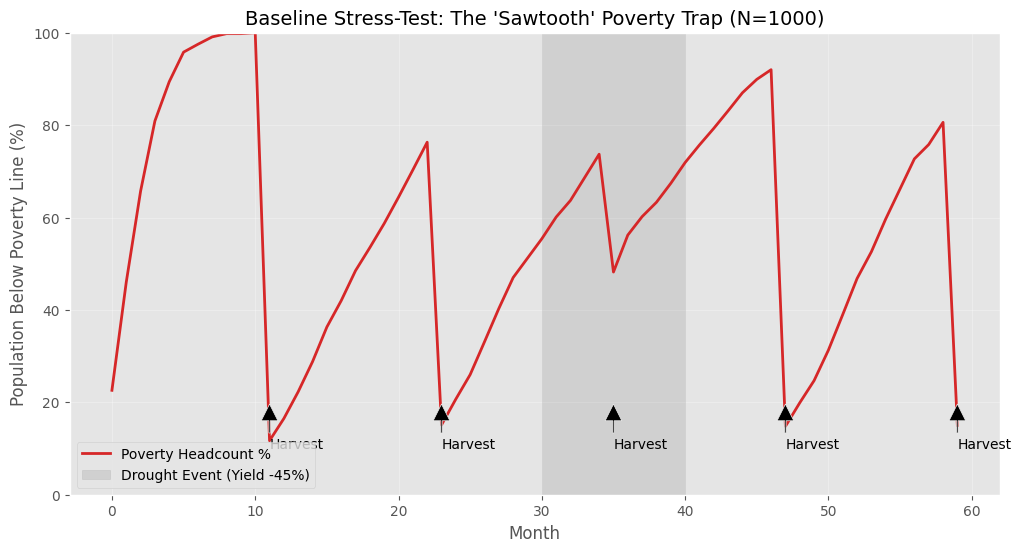

In [3]:
plt.figure(figsize=(12, 6))

# Plotting the Poverty Rate
plt.plot(baseline_results.index, baseline_results['Poverty_Rate'] * 100, 
         color='#d62728', linewidth=2, label='Poverty Headcount %')

# Highlight the Drought Period (programmed in model.py for months 30-40)
plt.axvspan(30, 40, color='gray', alpha=0.2, label='Drought Event (Yield -45%)')

# Annotate the Harvests
for year in range(5):
    plt.annotate('Harvest', xy=(11 + (year*12), 20), xytext=(11 + (year*12), 10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title("Baseline Stress-Test: The 'Sawtooth' Poverty Trap (N=1000)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Population Below Poverty Line (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Statistical Summary of the Baseline

In [4]:
final_poverty = baseline_results['Poverty_Rate'].iloc[-1] * 100
peak_poverty = baseline_results['Poverty_Rate'].max() * 100
avg_savings_end = baseline_results['Avg_Savings'].iloc[-1]

print(f"--- BASELINE EXECUTIVE SUMMARY ---")
print(f"Starting Poverty Rate: 25.40%")
print(f"Ending Poverty Rate: {final_poverty:.2f}%")
print(f"Peak Poverty Rate (during drought): {peak_poverty:.2f}%")
print(f"Final Average Household Savings: ${avg_savings_end:.2f}")

# Save results for comparison
baseline_results.to_csv('../data/results/baseline_control_results.csv')

--- BASELINE EXECUTIVE SUMMARY ---
Starting Poverty Rate: 25.40%
Ending Poverty Rate: 15.00%
Peak Poverty Rate (during drought): 100.00%
Final Average Household Savings: $1335.79
